In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    PolynomialFeatures,
    PowerTransformer,
    RobustScaler,
    StandardScaler,
    QuantileTransformer,
)

from src.config import DADOS_LIMPOS
from src.auxiliares import dataframe_coeficientes
from src.graficos import (
    plot_coeficientes,
    plot_comparar_metricas_modelos,
    plot_residuos_estimador,
)
from src.models import (
    organiza_resultados,
    treinar_e_validar_modelo_regressao,
    grid_search_cv_regressor,
)

In [2]:
df = pd.read_parquet(DADOS_LIMPOS)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,median_income_cat,rooms_per_household,population_per_household,bedrooms_per_room
0,-122.230003,37.880001,41,880,129,322,126,8.3252,452600,NEAR BAY,5,6.984127,2.555556,0.146591
1,-122.220001,37.860001,21,7099,1106,2401,1138,8.3014,358500,NEAR BAY,5,6.238137,2.109842,0.155797
2,-122.260002,37.840000,42,2555,665,1206,595,2.0804,226700,NEAR BAY,2,4.294117,2.026891,0.260274
3,-122.260002,37.849998,50,1120,283,697,264,2.1250,140000,NEAR BAY,2,4.242424,2.640152,0.252679
4,-122.260002,37.840000,50,2239,455,990,419,1.9911,158700,NEAR BAY,2,5.343676,2.362768,0.203216


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17564 entries, 0 to 17563
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   longitude                 17564 non-null  float32 
 1   latitude                  17564 non-null  float32 
 2   housing_median_age        17564 non-null  int8    
 3   total_rooms               17564 non-null  int16   
 4   total_bedrooms            17564 non-null  int16   
 5   population                17564 non-null  int16   
 6   households                17564 non-null  int16   
 7   median_income             17564 non-null  float32 
 8   median_house_value        17564 non-null  int32   
 9   ocean_proximity           17564 non-null  category
 10  median_income_cat         17564 non-null  int64   
 11  rooms_per_household       17564 non-null  float32 
 12  population_per_household  17564 non-null  float32 
 13  bedrooms_per_room         17564 non-null  floa

In [4]:
coluna_target = ["median_house_value"]

coluna_one_hot_encoder = ["ocean_proximity"] #Variavel categorica

coluna_ordinal_encoder = ["median_income_cat"] #variavel categorica ordinal

In [5]:
colunas_robust_scaler = df.columns.difference(coluna_target + coluna_one_hot_encoder + coluna_ordinal_encoder)#Esse coluna é pro nosso preprocessamento simples, onde estou pegando todas as colunas numericas e estou aplicando o mesmo scaler menos sensivel a outliers

colunas_robust_scaler

Index(['bedrooms_per_room', 'households', 'housing_median_age', 'latitude',
       'longitude', 'median_income', 'population', 'population_per_household',
       'rooms_per_household', 'total_bedrooms', 'total_rooms'],
      dtype='object')

In [6]:
#Vamos fazer um preprocessamento e ver se vale a pena o uso dessas features

In [7]:
pipeline_robust =  Pipeline(steps=[
    ("robust_scaler", RobustScaler()),
    ("poly", PolynomialFeatures(degree=1, include_bias=False))
])

preprocessamento = ColumnTransformer(
    transformers=[
        ("ordinal_encoder", OrdinalEncoder(categories="auto"), coluna_ordinal_encoder),#ele indentifica automaticamente as categorias
        ("one_hot", OneHotEncoder(drop="first"), coluna_one_hot_encoder),
        ("robust_scaler_poly", pipeline_robust, colunas_robust_scaler), #Eu vou passar em todas as outras colunas numericas
    ],
)


In [8]:
X = df.drop(columns=coluna_target)
y = df[coluna_target]

In [9]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_income_cat,rooms_per_household,population_per_household,bedrooms_per_room
0,-122.230003,37.880001,41,880,129,322,126,8.3252,NEAR BAY,5,6.984127,2.555556,0.146591
1,-122.220001,37.860001,21,7099,1106,2401,1138,8.3014,NEAR BAY,5,6.238137,2.109842,0.155797
2,-122.260002,37.840000,42,2555,665,1206,595,2.0804,NEAR BAY,2,4.294117,2.026891,0.260274
3,-122.260002,37.849998,50,1120,283,697,264,2.1250,NEAR BAY,2,4.242424,2.640152,0.252679
4,-122.260002,37.840000,50,2239,455,990,419,1.9911,NEAR BAY,2,5.343676,2.362768,0.203216


In [10]:
X.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_income_cat,rooms_per_household,population_per_household,bedrooms_per_room
count,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000,17564.000000
mean,-119.509995,35.602200,27.276873,2510.510875,515.378046,1386.315019,483.979447,3.696602,2.952460,5.253924,2.934664,0.211643
std,1.984252,2.147250,11.323957,1593.977891,320.848886,844.889138,295.559700,1.541925,1.006761,1.134085,0.691408,0.048315
min,-124.300003,32.540001,1.000000,6.000000,2.000000,3.000000,2.000000,0.499900,1.000000,1.714286,0.750000,0.113535
25%,-121.599998,33.919998,18.000000,1464.750000,300.000000,816.000000,287.000000,2.547375,2.000000,4.446466,2.470259,0.176919
50%,-118.459999,34.240002,28.000000,2131.000000,438.000000,1196.000000,415.000000,3.479200,3.000000,5.205450,2.852657,0.203465
75%,-117.980003,37.669998,36.000000,3124.000000,643.000000,1738.000000,605.000000,4.622525,4.000000,5.961016,3.306427,0.239151
max,-114.550003,41.950001,51.000000,11026.000000,2205.000000,5804.000000,1979.000000,10.594100,5.000000,10.352942,5.392954,0.406295


In [11]:
y.head()

,median_house_value
0,452600
1,358500
2,226700
3,140000
4,158700


In [12]:
param_grid = { #Grade de parametros
    "regressor__preprocessor__robust_scaler_poly__poly__degree": [1,2,3],
}

In [13]:
#GridSearch para avaliar target

In [14]:
grid_search = grid_search_cv_regressor(
    regressor=LinearRegression(),
    preprocessor=preprocessamento,
    target_transformer=QuantileTransformer(output_distribution="normal"),
    param_grid=param_grid,
)

grid_search

,estimator,TransformedTa...ion='normal'))
,param_grid,"{'regressor__preprocesso...aler_poly__poly__degree': [1, 2, ...]}"
,scoring,"['r2', 'neg_mean_absolute_error', ...]"
,n_jobs,-1
,refit,'neg_root_mean_squared_error'
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ordinal_encoder', ...), ('one_hot', ...), ...]"


In [15]:
grid_search.fit(X, y)

Fitting 5 folds for each of 3 candidates, totalling 15 fits


,estimator,TransformedTa...ion='normal'))
,param_grid,"{'regressor__preprocesso...aler_poly__poly__degree': [1, 2, ...]}"
,scoring,"['r2', 'neg_mean_absolute_error', ...]"
,n_jobs,-1
,refit,'neg_root_mean_squared_error'
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('ordinal_encoder', ...), ('one_hot', ...), ...]"


In [16]:
grid_search.best_params_

{'regressor__preprocessor__robust_scaler_poly__poly__degree': 3}

In [17]:
grid_search.best_score_

np.float64(-51119.552912044644)

In [18]:
#Features polinomiais

In [19]:
coefs = dataframe_coeficientes(
    grid_search.best_estimator_.regressor_["reg"].coef_.flatten(), #Basta achatar o array de coeficientes usando .flatten()
    grid_search.best_estimator_.regressor_["preprocessor"].get_feature_names_out(),
)

coefs

,coeficiente
robust_scaler_poly__longitude total_rooms,-306142.545905
robust_scaler_poly__housing_median_age total_rooms,-229843.820246
robust_scaler_poly__latitude total_rooms,-216329.559784
robust_scaler_poly__rooms_per_household total_bedrooms,-214968.452488
robust_scaler_poly__latitude population_per_household total_rooms,-212503.188014
...,...
robust_scaler_poly__households,165900.715604
robust_scaler_poly__longitude population,170422.663990
robust_scaler_poly__latitude population rooms_per_household,213883.369321
robust_scaler_poly__bedrooms_per_room households,218523.717099


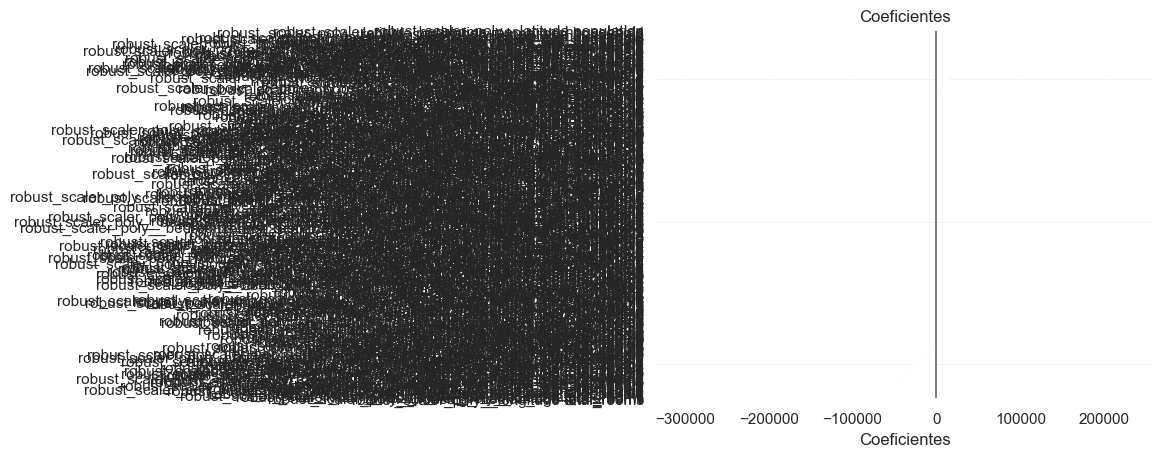

In [20]:
plot_coeficientes(coefs)

In [21]:
#vamos avaliar essa questão dos coeficientes porque como pode analisar foram criadas diversas colunas

In [22]:
coefs[coefs["coeficiente"] == 0]

,coeficiente


In [23]:
coefs[coefs["coeficiente"].between(-100_000, 100_000)]

,coeficiente
robust_scaler_poly__households housing_median_age population_per_household,-93033.548118
robust_scaler_poly__population_per_household total_bedrooms,-85759.392834
robust_scaler_poly__latitude population_per_household,-83324.291375
robust_scaler_poly__households^2 population_per_household,-66709.920057
robust_scaler_poly__housing_median_age population rooms_per_household,-64357.556687
...,...
robust_scaler_poly__housing_median_age total_bedrooms,73050.697794
robust_scaler_poly__bedrooms_per_room rooms_per_household total_rooms,75206.426068
robust_scaler_poly__latitude rooms_per_household,79289.123780
robust_scaler_poly__rooms_per_household^2,81847.384568


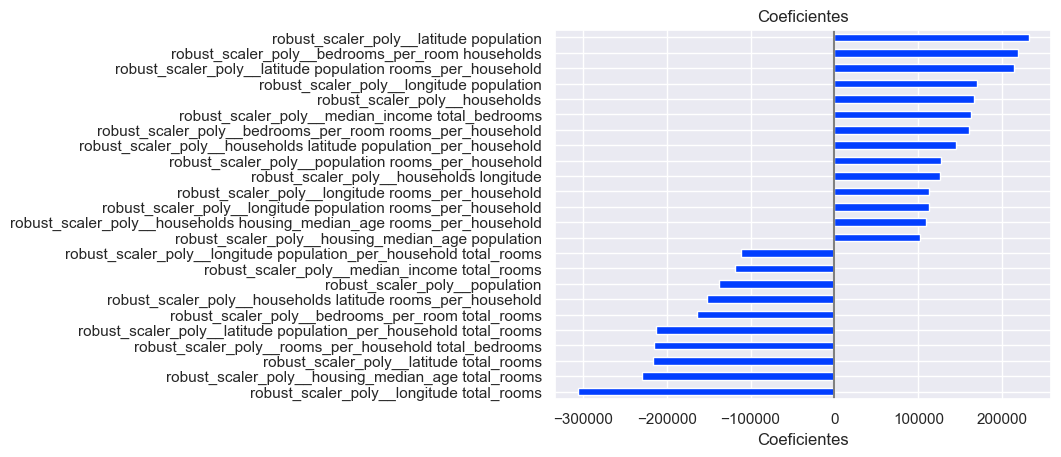

In [24]:
plot_coeficientes(coefs[~coefs["coeficiente"].between(-100_000, 100_000)]) #Esse ~ ele busca o que estão fora dessa caixa quem no contexto de negação

In [25]:
#Ou seja são 367 coeficientes que nenhum deles é zero ou seja nenhum deles tem uma determinadad feature que não tenha importancia

In [26]:
regressors = {
    "DummyRegressor": {
        "preprocessor": None,
        "regressor": DummyRegressor(strategy="mean"),
        "target_transformer": None,
    },
    "LinearRegression": {
        "preprocessor": preprocessamento,
        "regressor": LinearRegression(),
        "target_transformer": None,
    },
     "LinearRegression_target": {
        "preprocessor": preprocessamento,
        "regressor": LinearRegression(),
        "target_transformer": QuantileTransformer(output_distribution="normal"),
    },
    "LinearRegression_grid_search": {
        "preprocessor": grid_search.best_estimator_.regressor_["preprocessor"],
        "regressor": grid_search.best_estimator_.regressor_["reg"],
        "target_transformer": grid_search.best_estimator_.transformer_,
    },
}


resultados = {
    nome_modelo: treinar_e_validar_modelo_regressao(X, y, **regressor)
    for nome_modelo, regressor in regressors.items()
}

df_resultados = organiza_resultados(resultados)

df_resultados

,model,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
0,DummyRegressor,0.003687,0.004586,-0.000081,-77516.042766,-96239.705692,0.008274
1,DummyRegressor,0.003589,0.003738,-0.000146,-75787.787194,-95217.629397,0.007326
2,DummyRegressor,0.002498,0.003756,-0.001737,-76753.598961,-96253.253947,0.006254
3,DummyRegressor,0.002799,0.003552,-0.000101,-76837.804811,-95983.885799,0.00635
4,DummyRegressor,0.002476,0.003297,-0.000114,-76617.245449,-96182.764729,0.005772
5,LinearRegression,0.024595,0.009415,0.682162,-39855.690996,-54254.958188,0.034011
6,LinearRegression,0.023432,0.009293,0.66999,-40272.565467,-54695.230283,0.032726
7,LinearRegression,0.023638,0.008945,0.649247,-42178.05929,-56955.988706,0.032582
8,LinearRegression,0.022871,0.008779,0.669873,-40806.492497,-55146.318803,0.031649
9,LinearRegression,0.023738,0.009437,0.669023,-40788.496497,-55331.35106,0.033175


In [27]:
df_resultados.groupby("model").mean()

,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
model,,,,,,
DummyRegressor,0.00301,0.003786,-0.000436,-76702.495836,-95975.447913,0.006795
LinearRegression,0.023655,0.009174,0.668059,-40780.26095,-55276.769408,0.032828
LinearRegression_grid_search,0.27138,0.019997,0.715975,-35575.74784,-51125.365269,0.291377
LinearRegression_target,0.029476,0.009692,0.678128,-38676.989392,-54427.947963,0.039168


In [28]:
df_resultados.groupby("model").mean().sort_values(by="test_neg_root_mean_squared_error")

,fit_time,score_time,test_r2,test_neg_mean_absolute_error,test_neg_root_mean_squared_error,time_seconds
model,,,,,,
DummyRegressor,0.00301,0.003786,-0.000436,-76702.495836,-95975.447913,0.006795
LinearRegression,0.023655,0.009174,0.668059,-40780.26095,-55276.769408,0.032828
LinearRegression_target,0.029476,0.009692,0.678128,-38676.989392,-54427.947963,0.039168
LinearRegression_grid_search,0.27138,0.019997,0.715975,-35575.74784,-51125.365269,0.291377


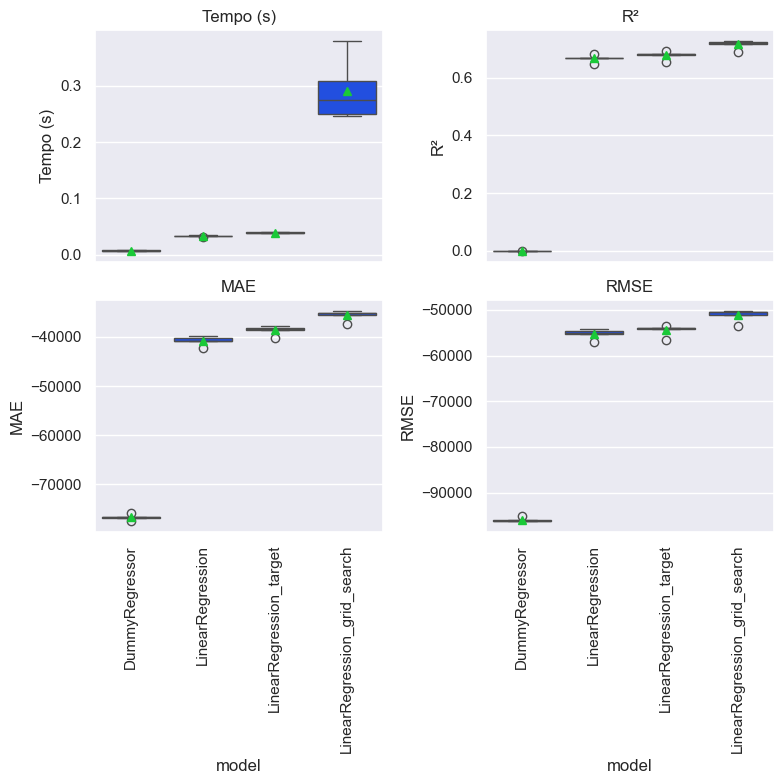

In [29]:
plot_comparar_metricas_modelos(df_resultados)

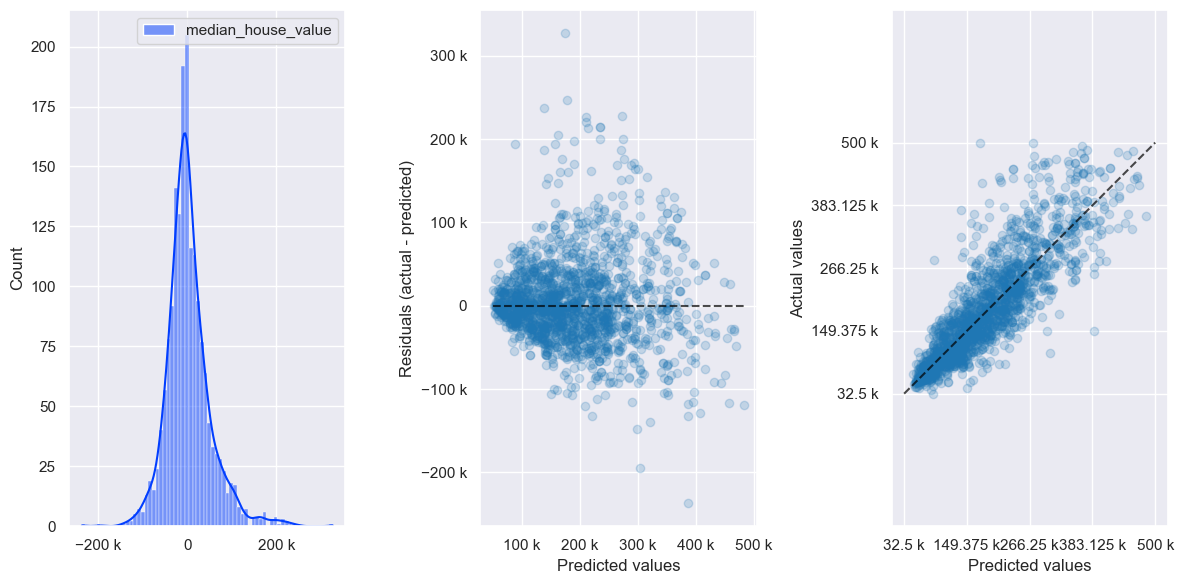

In [30]:
plot_residuos_estimador(grid_search.best_estimator_, X, y, fracao_amostra=0.1, eng_formatter=True)

In [31]:
#ElasticNet

In [32]:
#Vamos sair do modelo linear Regression para buscar essa questão dos coeficientes